# 📏 04 — Model Evaluation
### World Development Clustering Pipeline

---

**Purpose:** Comprehensive evaluation of all 5 clustering models — mirrors `cluster_evaluator.py` + Stage 8–9 of `training_pipeline.py`.  
**Input:** `data/processed/final_features.csv`, `models/*.pkl`, `data/processed/cleaned_data.csv`  
**Output:** `reports/evaluation_metrics.json`, model selection decision, GDP validation

---

### 🏆 Model Selection Logic
| Step | Rule |
|------|------|
| 1 | Remove models where any cluster < 5% of total samples (imbalance) |
| 2 | Rank remaining by **highest Silhouette** → **lowest Davies-Bouldin** |
| 3 | Prefer KMeans if within 0.01 of best silhouette (interpretability) |
| 4 | If KMeans not in range, prefer GMM or BIRCH over Agglomerative/Spectral |

---
## 1. Environment Setup

In [1]:
import os
import sys
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from collections import Counter
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from IPython.display import display

from config.config import (
    MODELS_DIR, REPORTS_DIR, PROCESSED_DIR,
    CLEANED_DATA, ID_COL,
    MIN_CLUSTER_SIZE, MAX_IMBALANCE_RATIO, MIN_CLUSTER_SIZE_PCT,
)
from src.utils.helpers import get_numeric_feature_cols

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})
PALETTE = sns.color_palette('tab10')
os.makedirs(REPORTS_DIR, exist_ok=True)

print('✅ Environment ready')

✅ Environment ready


---
## 2. Load Models and Feature Matrix

In [2]:
# ── Load final feature set ────────────────────────────────────────────────────
FINAL_FEATURES_PATH = os.path.join(PROCESSED_DIR, 'final_features.csv')
df = pd.read_csv(FINAL_FEATURES_PATH)

_LABEL_COLS = {'KMeans_Cluster','Hierarchical_Cluster','GMM_Cluster',
               'Spectral_Cluster','Birch_Cluster','GMM_Confidence'}
feat_cols   = [c for c in df.select_dtypes(include='number').columns if c not in _LABEL_COLS]
countries   = df[ID_COL].values if ID_COL in df.columns else None
X           = df[feat_cols].values

print(f'Feature matrix: {X.shape[0]} countries × {X.shape[1]} features')

# ── Load trained models ───────────────────────────────────────────────────────
def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

km_model       = load_pkl(os.path.join(MODELS_DIR, 'kmeans_model.pkl'))
gmm_model      = joblib.load(os.path.join(MODELS_DIR, 'gmm_model.pkl')) if os.path.exists(os.path.join(MODELS_DIR, 'gmm_model.pkl')) else None
hc_model       = load_pkl(os.path.join(MODELS_DIR, 'hierarchical_model.pkl'))
spectral_model = load_pkl(os.path.join(MODELS_DIR, 'spectral_model.pkl'))
birch_model    = load_pkl(os.path.join(MODELS_DIR, 'birch_model.pkl'))

models_loaded = {'KMeans': km_model, 'GMM': gmm_model,
                 'Agglomerative': hc_model, 'Spectral': spectral_model, 'BIRCH': birch_model}
for name, m in models_loaded.items():
    status = '✅' if m is not None else '❌ NOT FOUND'
    print(f'  {status}  {name}')

Feature matrix: 198 countries × 20 features
  ✅  KMeans
  ✅  GMM
  ✅  Agglomerative
  ✅  Spectral
  ✅  BIRCH


In [3]:
# ── Extract labels ────────────────────────────────────────────────────────────
km_labels       = km_model.predict(X)       if km_model      else None
gmm_labels      = gmm_model.predict(X)      if gmm_model     else None
hc_labels       = hc_model.labels_          if hc_model      else None
spectral_labels = spectral_model.labels_    if spectral_model else None
birch_labels    = birch_model.labels_       if birch_model   else None

# GMM covariance type from model
gmm_cov_type = gmm_model.covariance_type if gmm_model else 'unknown'

all_labels = {
    'KMeans'                    : km_labels,
    f'GMM ({gmm_cov_type})'     : gmm_labels,
    'Agglomerative'             : hc_labels,
    'Spectral'                  : spectral_labels,
    'BIRCH'                     : birch_labels,
}
print('Labels extracted for all models')

Labels extracted for all models


---
## 3. Core Metrics: Silhouette, Davies-Bouldin, Calinski-Harabasz

In [4]:
eval_results = []

for model_name, labels in all_labels.items():
    if labels is None:
        continue

    mask        = labels != -1
    X_eval      = X[mask]
    lbl_eval    = labels[mask]
    n_clusters  = len(set(lbl_eval))
    n_total     = len(lbl_eval)

    # Balance check: any cluster < MIN_CLUSTER_SIZE_PCT?
    counts         = Counter(int(l) for l in lbl_eval)
    min_count      = min(counts.values())
    min_pct_thresh = int(np.ceil(MIN_CLUSTER_SIZE_PCT * n_total))
    is_invalid     = min_count < min_pct_thresh

    sil = silhouette_score(X_eval, lbl_eval)
    db  = davies_bouldin_score(X_eval, lbl_eval)
    ch  = calinski_harabasz_score(X_eval, lbl_eval)

    bic = round(gmm_model.bic(X_eval), 2) if ('GMM' in model_name and gmm_model) else None
    aic = round(gmm_model.aic(X_eval), 2) if ('GMM' in model_name and gmm_model) else None

    result = {
        'model'            : model_name,
        'n_clusters'       : n_clusters,
        'noise_points'     : int((labels == -1).sum()),
        'silhouette_score' : round(sil, 4),
        'davies_bouldin'   : round(db, 4),
        'calinski_harabasz': round(ch, 4),
        'bic'              : bic,
        'aic'              : aic,
        'min_cluster_size' : min_count,
        'invalid'          : is_invalid,
        'cluster_sizes'    : dict(sorted(counts.items())),
    }
    eval_results.append(result)

    status = 'INVALID (imbalance)' if is_invalid else 'OK'
    print(f'[{model_name:<22}] sil={sil:.4f} | db={db:.4f} | ch={ch:.2f} | min_cluster={min_count} | {status}')

# Save metrics JSON
with open(os.path.join(REPORTS_DIR, 'evaluation_metrics.json'), 'w') as f:
    json.dump(eval_results, f, indent=2, default=str)
print('\n✅ evaluation_metrics.json saved')

[KMeans                ] sil=0.2237 | db=1.4700 | ch=57.93 | min_cluster=28 | OK
[GMM (diag)            ] sil=0.1749 | db=1.6825 | ch=52.02 | min_cluster=40 | OK
[Agglomerative         ] sil=0.2108 | db=1.2199 | ch=27.88 | min_cluster=2 | INVALID (imbalance)
[Spectral              ] sil=0.2164 | db=1.4965 | ch=55.21 | min_cluster=23 | OK
[BIRCH                 ] sil=0.1983 | db=1.4429 | ch=48.60 | min_cluster=19 | OK

✅ evaluation_metrics.json saved


---
## 4. Model Comparison Table & Selection

In [5]:
# ── Comparison table ──────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(eval_results)

# Step 1: Filter out invalid models
valid_df    = metrics_df[~metrics_df['invalid']].copy()
if valid_df.empty:
    valid_df = metrics_df.copy()
    print('⚠  All models invalid by imbalance — using full set')

# Step 2: Sort by silhouette desc, db asc
valid_df = valid_df.sort_values(['silhouette_score', 'davies_bouldin'],
                                 ascending=[False, True]).reset_index(drop=True)
best_sil   = valid_df.iloc[0]['silhouette_score']
best_model = valid_df.iloc[0]['model']

# Step 3: Prefer KMeans if within 0.01 of best
km_rows = valid_df[valid_df['model'].str.contains('KMeans', case=False)]
if not km_rows.empty:
    km_sil = km_rows.iloc[0]['silhouette_score']
    if abs(km_sil - best_sil) <= 0.01:
        best_model = km_rows.iloc[0]['model']

metrics_df['Selected'] = metrics_df['model'].apply(lambda m: '✅ YES' if m == best_model else 'No')

display_cols = ['model', 'n_clusters', 'silhouette_score', 'davies_bouldin',
                'calinski_harabasz', 'min_cluster_size', 'invalid', 'Selected']
display_cols = [c for c in display_cols if c in metrics_df.columns]

print('=' * 80)
print('MODEL COMPARISON TABLE')
print('=' * 80)
display(metrics_df[display_cols].sort_values('silhouette_score', ascending=False))
print('=' * 80)
print(f'  SELECTED MODEL: {best_model}')
print('=' * 80)

MODEL COMPARISON TABLE


,model,n_clusters,silhouette_score,davies_bouldin,calinski_harabasz,min_cluster_size,invalid,Selected
0,KMeans,4,0.2237,1.4700,57.9326,28,False,✅ YES
3,Spectral,4,0.2164,1.4965,55.2074,23,False,No
2,Agglomerative,4,0.2108,1.2199,27.8821,2,True,No
4,BIRCH,4,0.1983,1.4429,48.6007,19,False,No
1,GMM (diag),4,0.1749,1.6825,52.0210,40,False,No


  SELECTED MODEL: KMeans


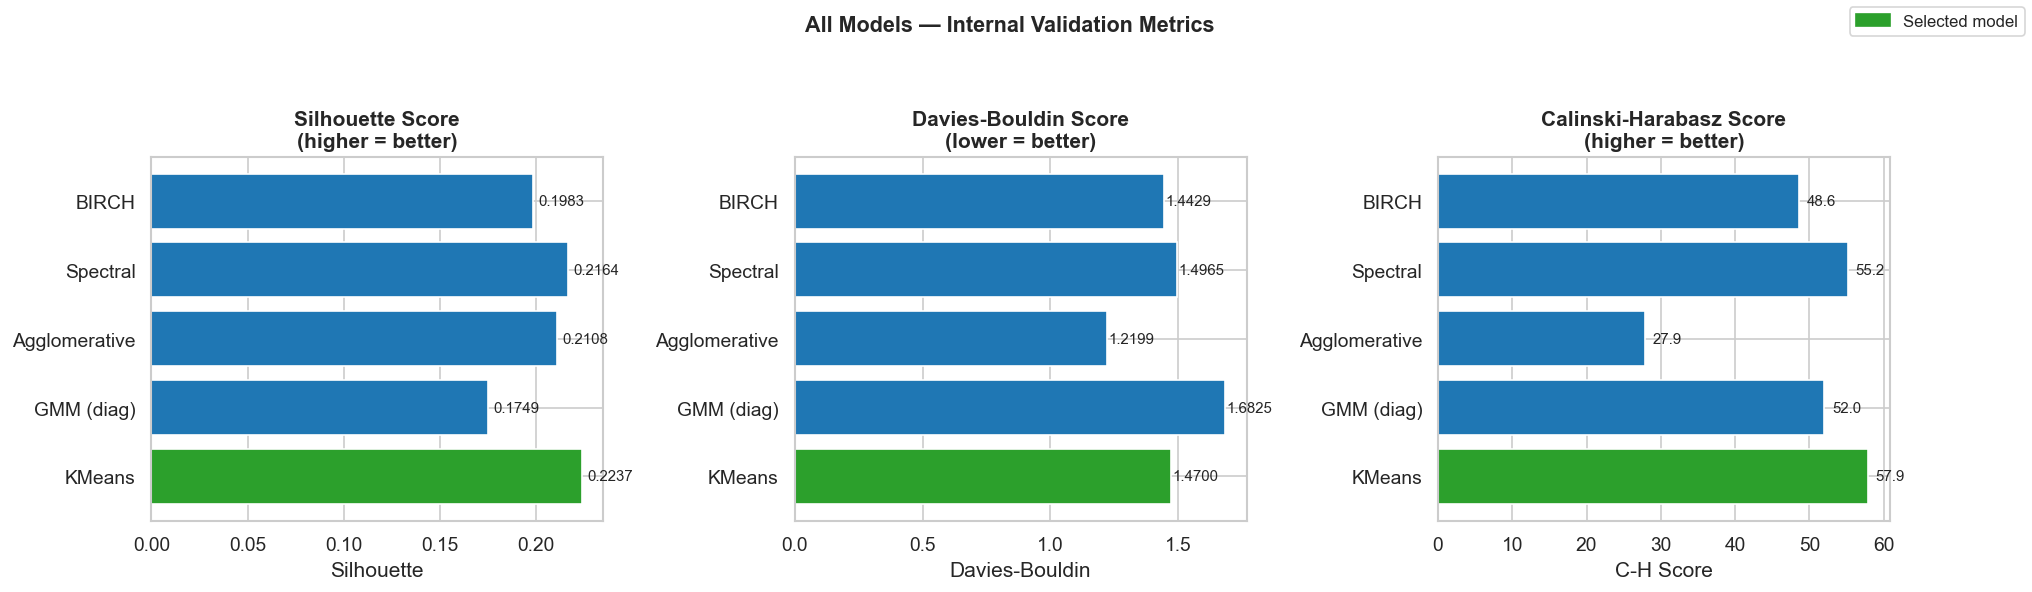

In [6]:
# ── Metric comparison bar charts ──────────────────────────────────────────────
models_list = metrics_df['model'].tolist()
colors      = ['#2ca02c' if m == best_model else '#1f77b4' for m in models_list]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Silhouette (higher = better)
sil_vals = metrics_df['silhouette_score'].values
axes[0].barh(models_list, sil_vals, color=colors)
axes[0].set_title('Silhouette Score\n(higher = better)', fontweight='bold')
axes[0].set_xlabel('Silhouette')
for i, v in enumerate(sil_vals):
    axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

# Davies-Bouldin (lower = better)
db_vals = metrics_df['davies_bouldin'].values
axes[1].barh(models_list, db_vals, color=colors)
axes[1].set_title('Davies-Bouldin Score\n(lower = better)', fontweight='bold')
axes[1].set_xlabel('Davies-Bouldin')
for i, v in enumerate(db_vals):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Calinski-Harabasz (higher = better)
ch_vals = metrics_df['calinski_harabasz'].values
axes[2].barh(models_list, ch_vals, color=colors)
axes[2].set_title('Calinski-Harabasz Score\n(higher = better)', fontweight='bold')
axes[2].set_xlabel('C-H Score')
for i, v in enumerate(ch_vals):
    axes[2].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

patch = mpatches.Patch(color='#2ca02c', label='Selected model')
fig.legend(handles=[patch], loc='upper right', fontsize=10)

plt.suptitle('All Models — Internal Validation Metrics', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.95, 0.93])
plt.show()

---
## 5. Silhouette Plots (per-sample analysis)

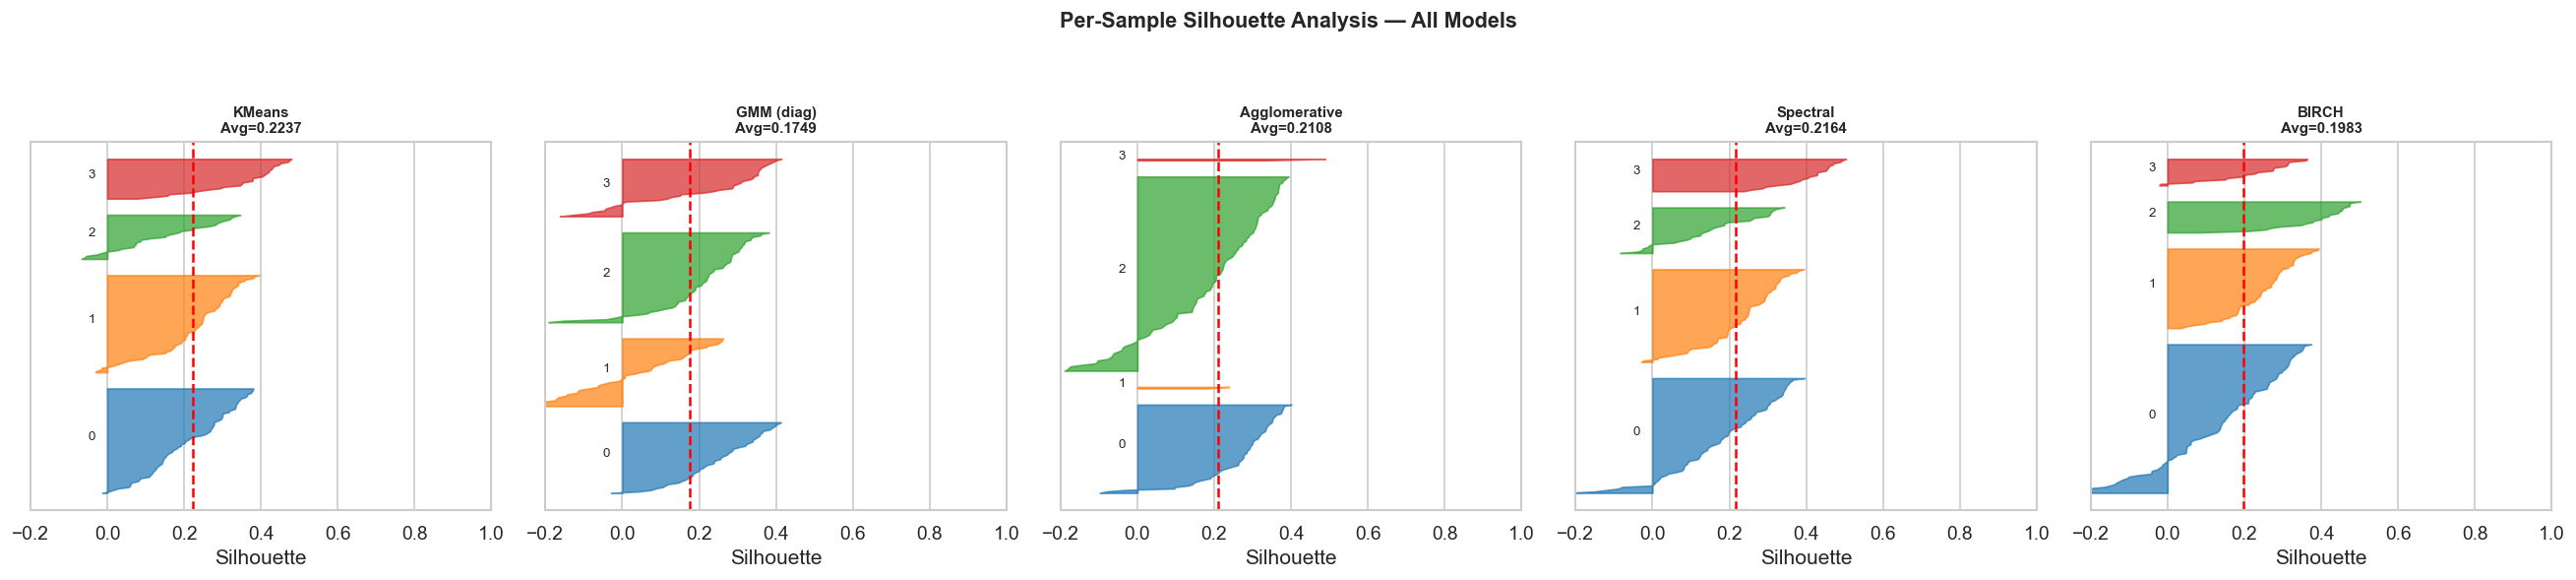

In [7]:
# ── Per-sample silhouette for all models ─────────────────────────────────────
fig, axes = plt.subplots(1, len(all_labels), figsize=(22, 5))

for ax, (model_name, labels) in zip(axes, all_labels.items()):
    if labels is None:
        ax.set_visible(False)
        continue

    n_clusters = len(set(labels))
    sil_vals   = silhouette_samples(X, labels)
    avg_sil    = silhouette_score(X, labels)

    y_lower = 10
    for i in range(n_clusters):
        cluster_sil = np.sort(sil_vals[labels == i])
        size_i      = cluster_sil.shape[0]
        y_upper     = y_lower + size_i
        color       = PALETTE[i % 10]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=8)
        y_lower = y_upper + 10

    ax.axvline(x=avg_sil, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'{model_name}\nAvg={avg_sil:.4f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Silhouette')
    ax.set_xlim(-0.2, 1.0)
    ax.set_yticks([])

plt.suptitle('Per-Sample Silhouette Analysis — All Models', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

---
## 6. Cluster Size Balance Analysis

2026-05-03 20:16:01 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-03 20:16:01 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-03 20:16:01 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-03 20:16:01 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-03 20:16:01 

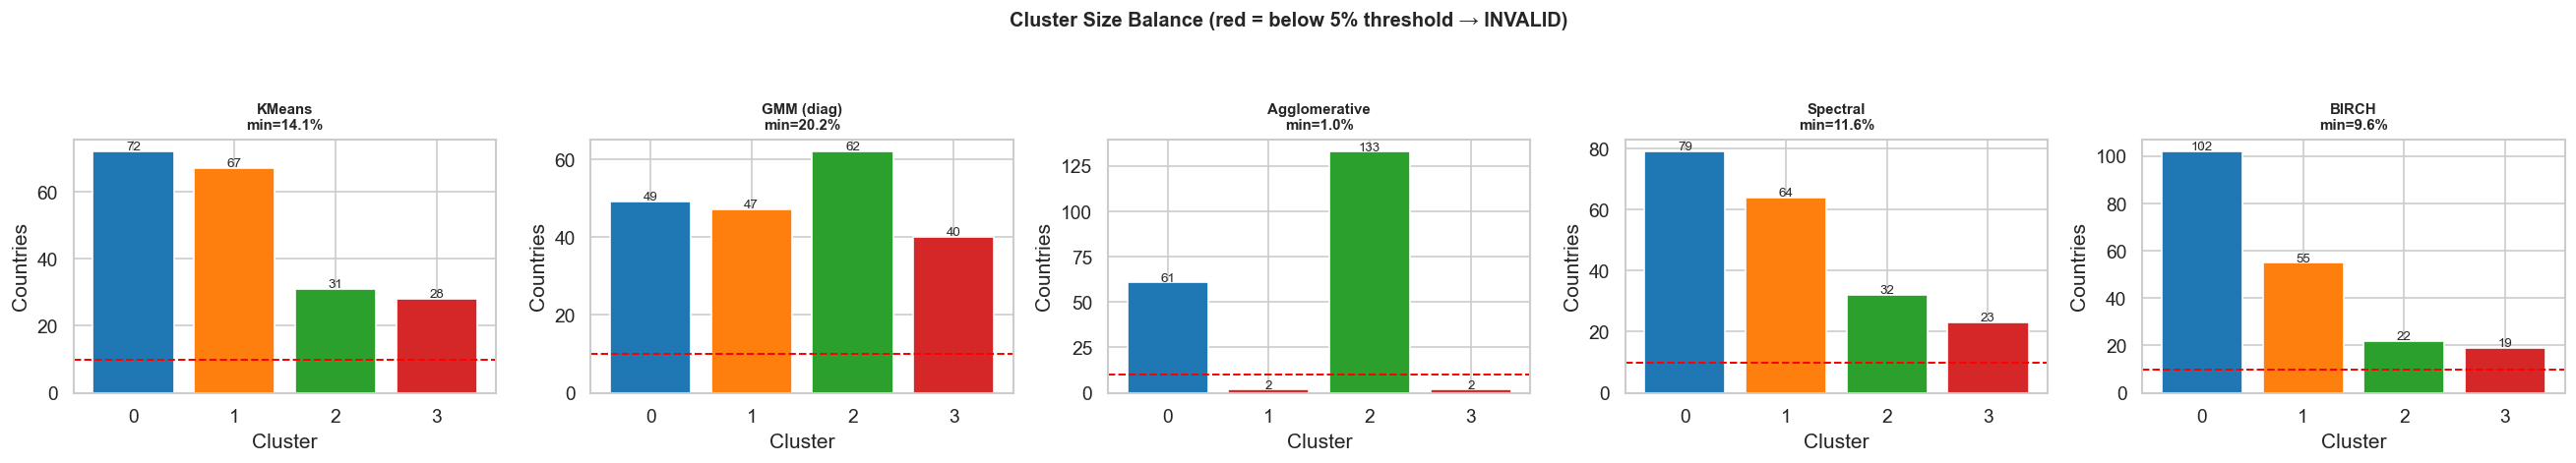

In [8]:
fig, axes = plt.subplots(1, len(all_labels), figsize=(22, 4))

for ax, (model_name, labels) in zip(axes, all_labels.items()):
    if labels is None:
        ax.set_visible(False)
        continue

    counts = Counter(int(l) for l in labels if l != -1)
    cluster_ids = sorted(counts.keys())
    sizes       = [counts[c] for c in cluster_ids]
    total       = sum(sizes)
    min_pct     = min(sizes) / total * 100

    colors_bar = ['#d62728' if s / total < MIN_CLUSTER_SIZE_PCT else PALETTE[i % 10]
                  for i, s in enumerate(sizes)]
    ax.bar([str(c) for c in cluster_ids], sizes, color=colors_bar)
    ax.axhline(MIN_CLUSTER_SIZE_PCT * total, color='red', linestyle='--', lw=1.2,
               label=f'{MIN_CLUSTER_SIZE_PCT*100:.0f}% threshold')
    ax.set_title(f'{model_name}\nmin={min_pct:.1f}%', fontweight='bold', fontsize=9)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Countries')
    for i, v in enumerate(sizes):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=8)

plt.suptitle(f'Cluster Size Balance (red = below {MIN_CLUSTER_SIZE_PCT*100:.0f}% threshold → INVALID)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

---
## 7. GMM Deep Dive — Probability Analysis

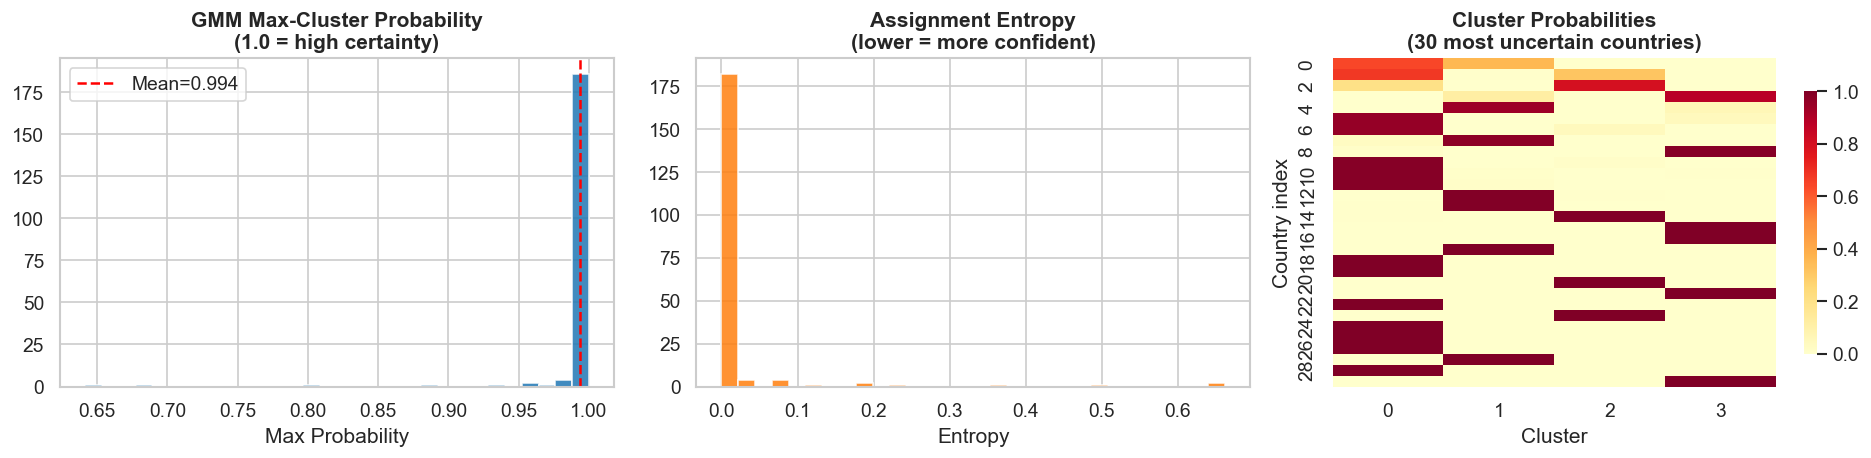

GMM Assignment Confidence:
  High confidence (>80%) : 195/198 countries (98.5%)
  Ambiguous (<50%)       : 0/198 countries (0.0%)


In [9]:
if gmm_model is not None:
    probs      = gmm_model.predict_proba(X)
    max_probs  = probs.max(axis=1)
    entropy    = -np.sum(probs * np.log(probs + 1e-10), axis=1)  # assignment uncertainty

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Max probability distribution
    axes[0].hist(max_probs, bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
    axes[0].axvline(max_probs.mean(), color='red', linestyle='--',
                    label=f'Mean={max_probs.mean():.3f}')
    axes[0].set_title('GMM Max-Cluster Probability\n(1.0 = high certainty)', fontweight='bold')
    axes[0].set_xlabel('Max Probability')
    axes[0].legend()

    # Entropy (lower = more certain)
    axes[1].hist(entropy, bins=30, color=PALETTE[1], edgecolor='white', alpha=0.85)
    axes[1].set_title('Assignment Entropy\n(lower = more confident)', fontweight='bold')
    axes[1].set_xlabel('Entropy')

    # Heatmap of probabilities
    k = gmm_model.n_components
    top30_idx = np.argsort(max_probs)[:30]  # most uncertain 30
    sns.heatmap(probs[top30_idx], ax=axes[2], cmap='YlOrRd', vmin=0, vmax=1,
                cbar_kws={'shrink': 0.8})
    axes[2].set_title('Cluster Probabilities\n(30 most uncertain countries)', fontweight='bold')
    axes[2].set_xlabel('Cluster')
    axes[2].set_ylabel('Country index')

    plt.tight_layout()
    plt.show()

    n_high_conf = int((max_probs > 0.8).sum())
    n_ambig     = int((max_probs < 0.5).sum())
    print(f'GMM Assignment Confidence:')
    print(f'  High confidence (>80%) : {n_high_conf}/{len(max_probs)} countries ({n_high_conf/len(max_probs)*100:.1f}%)')
    print(f'  Ambiguous (<50%)       : {n_ambig}/{len(max_probs)} countries ({n_ambig/len(max_probs)*100:.1f}%)')

---
## 8. GDP Proxy Validation (External Validity)

In [10]:
# ── Load original-scale cleaned data for GDP validation ──────────────────────
df_cleaned = pd.read_csv(CLEANED_DATA)

# Map best model to cluster column
_MODEL_TO_COL = {
    'KMeans'      : 'KMeans_Cluster',
    'Agglomerative': 'Hierarchical_Cluster',
    'Spectral'    : 'Spectral_Cluster',
    'BIRCH'       : 'Birch_Cluster',
}
best_cluster_col = _MODEL_TO_COL.get(best_model, 'GMM_Cluster')
if 'GMM' in best_model:
    best_cluster_col = 'GMM_Cluster'

# Build df with best model's labels
df_eval = df.copy()
best_labels = dict([
    ('KMeans', km_labels),
    (f'GMM ({gmm_cov_type})', gmm_labels),
    ('Agglomerative', hc_labels),
    ('Spectral', spectral_labels),
    ('BIRCH', birch_labels),
])
df_eval[best_cluster_col] = best_labels[best_model]

if 'Country' in df_cleaned.columns and 'GDP' in df_cleaned.columns:
    df_val = df_cleaned[['Country', 'GDP']].merge(
        df_eval[['Country', best_cluster_col]], on='Country', how='inner'
    ) if ID_COL in df_eval.columns else None

    if df_val is not None and len(df_val) > 0:
        df_val['GDP_Quartile'] = pd.qcut(df_val['GDP'], q=4,
                                          labels=['Q1_Low','Q2_LowMid','Q3_UpperMid','Q4_High'])
        crosstab = pd.crosstab(df_val['GDP_Quartile'], df_val[best_cluster_col], margins=True)

        print(f'GDP Quartile × Cluster Cross-tabulation ({best_model}):')
        display(crosstab)

        # Alignment score: dominant fraction per quartile
        alignment_scores = []
        for quartile in ['Q1_Low', 'Q2_LowMid', 'Q3_UpperMid', 'Q4_High']:
            if quartile not in crosstab.index:
                continue
            row   = crosstab.loc[quartile].drop('All')
            dom_f = row.max() / row.sum()
            alignment_scores.append(dom_f)
            ok = '✅' if dom_f > 0.5 else '⚠ '
            print(f'  {ok}  {quartile}: {dom_f*100:.1f}% in Cluster {row.idxmax()}')

        avg_alignment = np.mean(alignment_scores)
        print(f'\n  Average GDP alignment score: {avg_alignment:.3f}  ({"GOOD" if avg_alignment >= 0.5 else "POOR"})')

        crosstab.to_csv(os.path.join(REPORTS_DIR, f'gdp_validation_{best_cluster_col}.csv'))
        print(f'  Saved: gdp_validation_{best_cluster_col}.csv')

GDP Quartile × Cluster Cross-tabulation (KMeans):


KMeans_Cluster,0,1,2,3,All
GDP_Quartile,,,,,
Q1_Low,20,29,0,0,49
Q2_LowMid,21,26,0,1,48
Q3_UpperMid,25,9,10,4,48
Q4_High,4,1,21,23,49
All,70,65,31,28,194


  ✅  Q1_Low: 59.2% in Cluster 1
  ✅  Q2_LowMid: 54.2% in Cluster 1
  ✅  Q3_UpperMid: 52.1% in Cluster 0
  ⚠   Q4_High: 46.9% in Cluster 3

  Average GDP alignment score: 0.531  (GOOD)
  Saved: gdp_validation_KMeans_Cluster.csv


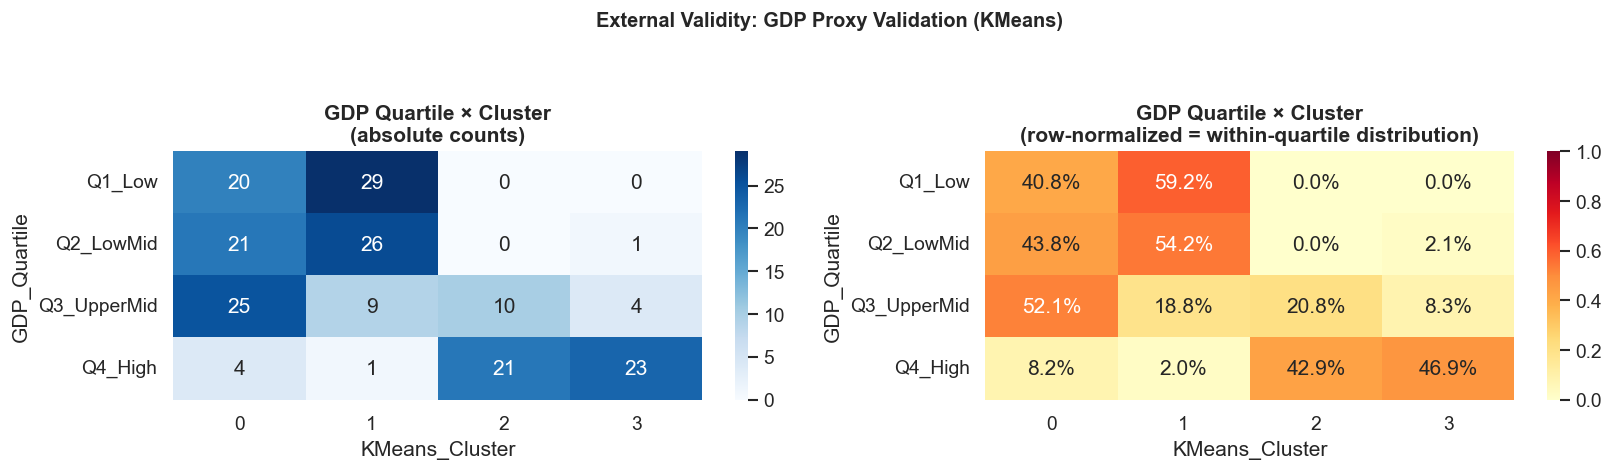

In [11]:
# ── GDP alignment heatmap ─────────────────────────────────────────────────────
if 'crosstab' in dir() and crosstab is not None:
    ct_plot = crosstab.drop('All').drop('All', axis=1, errors='ignore').astype(float)
    ct_norm = ct_plot.div(ct_plot.sum(axis=1), axis=0)  # row-normalize

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(ct_plot, annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'GDP Quartile × Cluster\n(absolute counts)', fontweight='bold')

    sns.heatmap(ct_norm, annot=True, fmt='.1%', cmap='YlOrRd', ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title(f'GDP Quartile × Cluster\n(row-normalized = within-quartile distribution)', fontweight='bold')

    plt.suptitle(f'External Validity: GDP Proxy Validation ({best_model})', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

---
## 9. Feature Importance by Cluster (z-score)

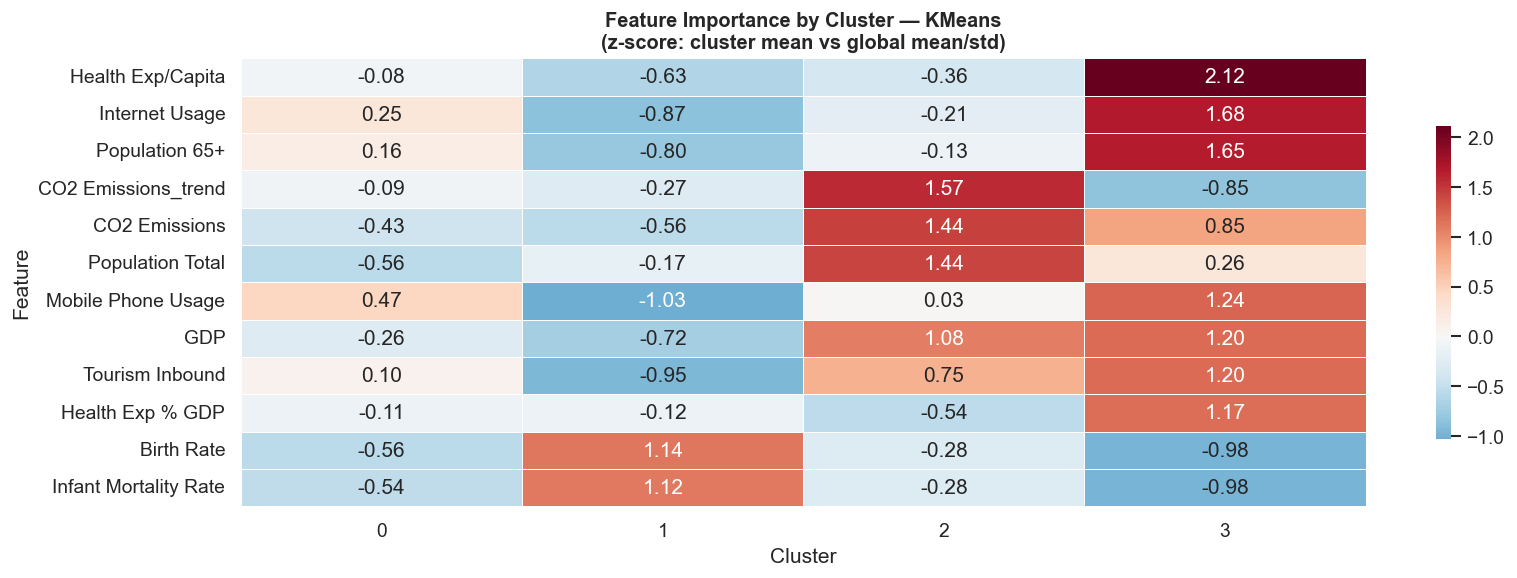

✅ feature_importance_KMeans_Cluster.csv saved


In [12]:
# ── Cluster-wise z-score feature importance ───────────────────────────────────
# (cluster_mean - global_mean) / global_std  → which features most discriminate each cluster
df_best = df.copy()
df_best[best_cluster_col] = best_labels[best_model]

feat_cols = [c for c in df.select_dtypes(include='number').columns
             if c not in _LABEL_COLS]

global_mean   = df_best[feat_cols].mean()
global_std    = df_best[feat_cols].std().replace(0, 1)
cluster_means = df_best.groupby(best_cluster_col)[feat_cols].mean()
importance_df = (cluster_means - global_mean) / global_std

importance_df.to_csv(os.path.join(REPORTS_DIR, f'feature_importance_{best_cluster_col}.csv'))

# Plot heatmap
# Select top discriminating features
top_n        = 12
abs_max      = importance_df.abs().max(axis=0).nlargest(top_n).index
imp_plot     = importance_df[abs_max]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(imp_plot.T, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title(f'Feature Importance by Cluster — {best_model}\n(z-score: cluster mean vs global mean/std)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print(f'✅ feature_importance_{best_cluster_col}.csv saved')

---
## 10. Evaluation Summary

In [13]:
print('=' * 70)
print('EVALUATION SUMMARY')
print('=' * 70)

best_row = metrics_df[metrics_df['model'] == best_model].iloc[0]
print(f'  Selected model     : {best_model}')
print(f'  Silhouette score   : {best_row.silhouette_score:.4f}')
print(f'  Davies-Bouldin     : {best_row.davies_bouldin:.4f}')
print(f'  Calinski-Harabasz  : {best_row.calinski_harabasz:.4f}')
print(f'  Cluster sizes      : {best_row.cluster_sizes}')
print(f'  Cluster column     : {best_cluster_col}')

reasons = []
if not best_row.invalid:
    reasons.append('Balanced clusters (all > 5%)')
if best_row.silhouette_score >= 0.2:
    reasons.append(f'Good silhouette ({best_row.silhouette_score:.4f})')
if 'KMeans' in best_model:
    reasons.append('Interpretable centroids')
print(f'  Selection reasons  : {" | ".join(reasons)}')

print('=' * 70)
print('\n✅ Evaluation complete — proceed to Notebook 05: Cluster Profiling')

EVALUATION SUMMARY
  Selected model     : KMeans
  Silhouette score   : 0.2237
  Davies-Bouldin     : 1.4700
  Calinski-Harabasz  : 57.9326
  Cluster sizes      : {0: 72, 1: 67, 2: 31, 3: 28}
  Cluster column     : KMeans_Cluster
  Selection reasons  : Balanced clusters (all > 5%) | Good silhouette (0.2237) | Interpretable centroids

✅ Evaluation complete — proceed to Notebook 05: Cluster Profiling
